<a href="https://colab.research.google.com/github/bollaprashanth09/prashanth_python/blob/main/Module_5_Stock_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Upload Dataset

In [ ]:
from google.colab import files

Step 2: Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score

Step 3: Load Dataset

In [7]:
df = pd.read_csv('stock_data.csv')
df.head()

,Unnamed: 0,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
0,2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
1,2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2,2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
3,2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
4,2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283


Step 4: Data Preprocessing

In [23]:
# Check null values
print(df.isnull().sum())

# Fill missing values
df.fillna(method='ffill', inplace=True)

# Convert Date column if exists
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])

Unnamed: 0    0
Stock_1       0
Stock_2       0
Stock_3       0
Stock_4       0
Stock_5       0
Price_Up      0
dtype: int64


/tmp/ipykernel_191/3730445022.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Step 5: Feature Selection

In [11]:
features = ['Stock_2', 'Stock_3', 'Stock_4']
target = 'Stock_1'

X = df[features]
y = df[target]

Step 6: Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

Step 7: Linear Regression (Price Prediction)

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 44.76110800359873


Step 8: Visualization

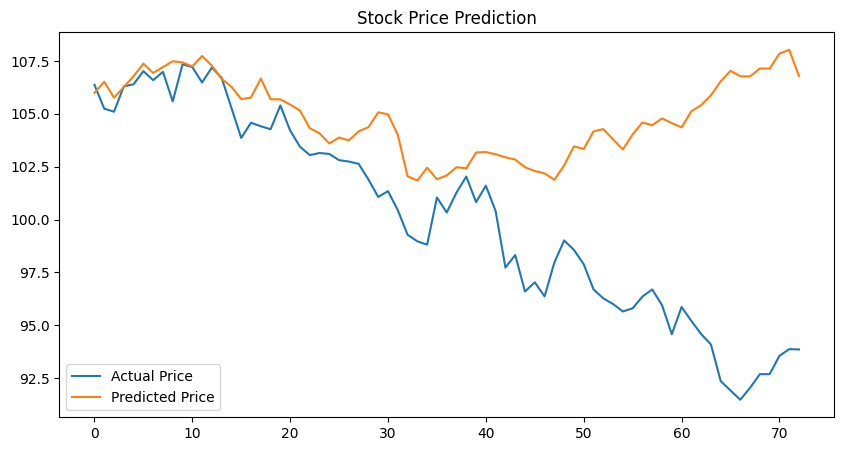

In [15]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')
plt.legend()
plt.title("Stock Price Prediction")
plt.show()

Step 9: Logistic Regression (Up/Down Prediction)

In [19]:
df['Price_Up'] = (df['Stock_1'].shift(-1) > df['Stock_1']).astype(int)

df.dropna(inplace=True)

X = df[['Stock_2', 'Stock_3', 'Stock_4']]
y = df['Price_Up']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred_class = log_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_class)
print("Accuracy:", accuracy)

Accuracy: 0.547945205479452


Step 10: Final Output

In [24]:

print("Linear Regression → Price Prediction")
print("Logistic Regression → Up/Down Prediction")

Linear Regression → Price Prediction
Logistic Regression → Up/Down Prediction
